# Cryptocurrency Price Prediction using LSTM

> A deep learning pipeline that predicts Bitcoin closing prices using an LSTM (Long Short-Term Memory) neural network, trained on historical price data from Kaggle.


## 📌 Project Overview

| Detail | Description |
|--------|-------------|
| **Goal** | Predict future Bitcoin closing prices |
| **Dataset** | [Kaggle - Cryptocurrency Price History](https://www.kaggle.com/datasets/sudalairajkumar/cryptocurrencypricehistory) |
| **Algorithm** | LSTM (Long Short-Term Memory) Neural Network |
| **Input Feature** | `Close` price only |
| **Evaluation** | RMSE (Root Mean Squared Error) |
| **Visualization** | Actual vs Predicted price chart |

## Imports & Dependencies

| Library | Purpose |
|--------|---------|
| `kagglehub` | Downloads dataset directly from Kaggle |
| `pandas` | Data loading and manipulation |
| `numpy` | Numerical operations and array handling |
| `matplotlib` | Plotting Actual vs Predicted prices |
| `MinMaxScaler` | Scales price values between 0 and 1 |
| `mean_squared_error` | Calculates prediction error |
| `Sequential`, `LSTM`, `Dense` | Builds the deep learning model |
| `np.random.seed(42)` | Ensures reproducible results |

In [1]:
import kagglehub
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

np.random.seed(42)

## Dataset Loading
- Dataset is downloaded automatically via `kagglehub`
- File used: `coin_Bitcoin.csv` — historical Bitcoin prices
- Contains columns like `Date`, `Open`, `High`, `Low`, `Close`, `Volume`
- We only use the **`Close`** column (closing price per day)

> 💡 Bitcoin closing price = the final price at the end of each trading day

In [8]:
path = kagglehub.dataset_download("sudalairajkumar/cryptocurrencypricehistory")
print("Dataset Path:", path)

df = pd.read_csv(path + "/coin_Bitcoin.csv")

Using Colab cache for faster access to the 'cryptocurrencypricehistory' dataset.
Dataset Path: /kaggle/input/cryptocurrencypricehistory


## 🧹  Data Cleaning

- `pd.to_numeric(..., errors="coerce")` converts any non-numeric values in `Close` to `NaN`
- `.dropna()` removes those missing rows
- We keep only the `Close` column — this is a **univariate time series** problem

In [9]:
df["Close"] = pd.to_numeric(df["Close"], errors="coerce")
df = df[["Close"]].dropna()

## Feature Scaling (MinMaxScaler)

- `MinMaxScaler` compresses all price values into the range **[0, 1]**
- Neural networks train much better on small, normalized values
- The scaler is saved so we can **inverse transform** predictions back to real prices later

In [10]:
scaler = MinMaxScaler()
data = scaler.fit_transform(df)

## Creating Sequences (Sliding Window)

- **Window size = 50** — the model looks at the last 50 days to predict the next day
- `X` → sequences of 50 closing prices (input)
- `y` → the very next closing price (target/label)
- This is how time series data is structured for LSTM

**Example:**
- Input: Days 1–50 → Predict: Day 51
- Input: Days 2–51 → Predict: Day 52
- ...and so on

> 💡 Larger window = more historical context, but slower training

In [11]:
def create_data(data, window=50):
    X, y = [], []
    for i in range(window, len(data)):
        X.append(data[i-window:i])
        y.append(data[i])
    return np.array(X), np.array(y)

WINDOW = 50
X, y = create_data(data, WINDOW)

## Reshape for LSTM

- LSTM expects input shape: `(samples, timesteps, features)`
- We reshape `X` from 2D to 3D: `(samples, 50, 1)`
- `1` = one feature (closing price only)

In [12]:
X = X.reshape((X.shape[0], X.shape[1], 1))

## Section 7 — Train/Test Split

| Parameter | Value | Meaning |
|-----------|-------|---------|
| `test_size=0.2` | 20% | Last 20% of data used for testing |
| `shuffle=False` | Disabled | Time order must be preserved — no random shuffling |

> ⚠️ `shuffle=False` is critical for time series — shuffling would cause data leakage from the future

In [13]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, shuffle=False
)

## Build the LSTM Model

| Layer | Details |
|-------|---------|
| `LSTM(50)` | 50 memory units, reads the 50-day sequence |
| `return_sequences=False` | Only returns the final output (not all timesteps) |
| `Dense(1)` | Output layer — predicts a single price value |

**What is LSTM?**
LSTM (Long Short-Term Memory) is a special type of neural network designed for sequential/time series data. It has memory cells that can remember patterns over long sequences — making it perfect for stock and crypto price prediction.

In [14]:
model = Sequential([
    LSTM(50, return_sequences=False, input_shape=(WINDOW, 1)),
    Dense(1)
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


## Compile the Model

| Setting | Value | Meaning |
|---------|-------|---------|
| `optimizer` | `adam` | Adaptive learning rate — efficient and widely used |
| `loss` | `mse` | Mean Squared Error — standard loss for regression problems |

> 💡 MSE penalizes large errors more heavily — good for price prediction where big misses matter

In [15]:
model.compile(optimizer="adam", loss="mse")

## Train the Model

| Parameter | Value | Meaning |
|-----------|-------|---------|
| `epochs=10` | 10 | Model sees the entire training data 10 times |
| `batch_size=32` | 32 | Updates weights after every 32 samples |
| `verbose=1` | Enabled | Shows training progress per epoch |

> 💡 More epochs = better learning, but risk of overfitting. 10 is a good starting point.

In [16]:
model.fit(X_train, y_train, epochs=10, batch_size=32, verbose=1)

Epoch 1/10
74/74 ━━━━━━━━━━━━━━━━━━━━ 4s 20ms/step - loss: 3.5309e-04
Epoch 2/10
74/74 ━━━━━━━━━━━━━━━━━━━━ 3s 24ms/step - loss: 7.5283e-05
Epoch 3/10
74/74 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 6.4459e-05
Epoch 4/10
74/74 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 5.6606e-05
Epoch 5/10
74/74 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 5.6707e-05
Epoch 6/10
74/74 ━━━━━━━━━━━━━━━━━━━━ 2s 27ms/step - loss: 5.1177e-05
Epoch 7/10
74/74 ━━━━━━━━━━━━━━━━━━━━ 2s 31ms/step - loss: 4.6505e-05
Epoch 8/10
74/74 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - loss: 4.4551e-05
Epoch 9/10
74/74 ━━━━━━━━━━━━━━━━━━━━ 3s 32ms/step - loss: 3.9534e-05
Epoch 10/10
74/74 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 3.8422e-05


In [17]:
pred = model.predict(X_test)

19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step


## Inverse Transform (Back to Real Prices)

- `scaler.inverse_transform()` converts scaled values back to actual USD prices
- Both `y_test` (actual) and `pred` (predicted) are inverse-transformed
- Now we can compare real prices vs predicted prices meaningfully

In [18]:
y_test_real = scaler.inverse_transform(y_test)
pred_real = scaler.inverse_transform(pred)

## Evaluation: RMSE

**RMSE = Root Mean Squared Error**
- Measures the average difference between actual and predicted prices (in USD)
- Lower RMSE = better predictions

| RMSE Range | Meaning |
|------------|---------|
| Very low | Model predictions are close to actual prices |
| Very high | Model is far off — needs more tuning |

**Formula:**
> 💡 For Bitcoin (price in thousands of USD), an RMSE of a few hundred dollars is considered good


## What is RMSE? (Quick Reference)

| Term | Meaning |
|------|---------|
| **R** | Root — we take the square root at the end |
| **M** | Mean — average across all predictions |
| **S** | Squared — each error is squared (penalizes big errors) |
| **E** | Error — difference between actual and predicted value |

In [21]:
rmse = np.sqrt(mean_squared_error(y_test_real, pred_real))
print("RMSE:", rmse)

RMSE: 3974.1785712253154


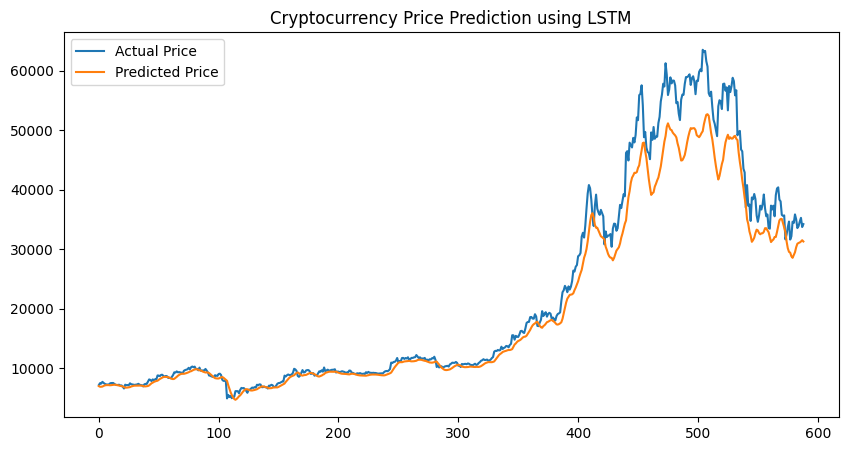

In [20]:
plt.figure(figsize=(10,5))
plt.plot(y_test_real, label="Actual Price")
plt.plot(pred_real, label="Predicted Price")
plt.title("Cryptocurrency Price Prediction using LSTM")
plt.legend()
plt.show()